**ФЕДЕРАЛЬНОЕ АГЕНСТВО ЖЕЛЕЗНОДОРОЖНОГО ТРАНСПОРТА**

Федеральное государственное бюджетное образовательное учреждение высшего образования

«ПЕТЕРБУРГСКИЙ ГОСУДАРСТВЕННЫЙ УНИВЕРСИТЕТ ПУТЕЙ СООБЩЕНИЯ Императора Александра I»

---

**Кафедра «Информационные и вычислительные системы»**

Дисциплина «Архитектура вычислительных систем»

**ОТЧЁТ**

**ПО ЛАБОРАТОРНОЙ РАБОТЕ №4**

**«ИССЛЕДОВАНИЕ АРХИТЕКТУРНЫХ СПОСОБОВ ПОВЫШЕНИЯ ПРОИЗВОДИТЕЛЬНОСТИ ВЫЧИСЛИТЕЛЬНЫХ СИСТЕМ»**

---

Выполнил студент

Факультет: АИТ

Группа: ИВБ-211

А. Шефнер

---

Проверил:

доц. каф. "ИВС"

В.А. Гончаренко

# Цель занятия

Изучение принципов конвейеризации, суперскалярной и VLIW-
обработки, архитектуры памяти и механизмов обеспечения когерентности
кэш-памяти в многопроцессорных системах; получение практических навыков
оценки эффективности различных архитектурных решений с использованием
расчётов и моделирования.

# Ход работы

Импорты для всего блокнота

In [1]:
from dataclasses import asdict, dataclass, is_dataclass
from math import ceil, sqrt
from random import randint

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from IPython.display import HTML
from matplotlib.patches import FancyArrowPatch

Функции отображения табличных данных

In [2]:
def render_cell(cell):
    if cell is None:
        cell = "-"
    return f"        <td>{cell}</td>\n"


def display_table_lists(data, headers=None):
    result = "<table>\n"

    if headers:
        result += "  <thead>\n"
        result += "    <tr>\n"
        for header in headers:
            result += f"      <th>{header}</th>"
        result += "    </tr>\n"
        result += "  </thead>\n"

    result += "  <tbody>\n"
    for row in data:
        result += "    <tr>\n"

        if is_dataclass(row):
            for key, value in asdict(row).items():
                result += render_cell(value)
        else:
            for cell in row:
                result += render_cell(cell)

        result += "    </tr>\n"
    result += "  </tbody>\n"
    result += "</table>\n"
    display(HTML(result))


def display_table_dicts(data, headers=None):
    keys = list(data[0].keys())
    data = [[dic[key] for key in dic] for dic in data]
    headers = headers if headers else keys
    display_table_lists(data, headers)


def display_table_dataclasses(data, headers=None):
    display_table_dicts([asdict(obj) for obj in data], headers)


def display_table(data, headers=None):
    first = data[0]
    if isinstance(first, list):
        display_table_lists(data, headers)
    elif isinstance(first, dict):
        display_table_dicts(data, headers)
    elif is_dataclass(first):
        display_table_dataclasses(data, headers)
    else:
        raise ValueError("Unsupported type")

## Исходные данные по варианту

In [3]:
@dataclass
class VariantData:
    # K - Чисто ступеней конвеера
    conveyor_steps: int

    # t_ступ - Длительность ступени (нс)
    step_time: int

    # N = количество команд для заданий 1-2
    ops: int

    # F - Число функциональных блоков (суперскаляр)
    func_blocks: int

    # P - Число процессоров в системе
    processors: int

    # t_loc - Время локального доступа (нс)
    local_time: int

    # t_rem - Время удалённого доступа (нс)
    remote_time: int

    # t_uma - Время доступа в UMA (нс)
    uma_time: int

    # p - доля локальных обращений (для NUMA)
    numa_accesses: float

    # M - Параметр для VLIV (количество операций в списке)
    vliw_ops: imt


def get_variant_data(group, number):
    g = int(group[-3:])
    s = number % 100
    local_time = 50 + (s % 20)
    return VariantData(
        conveyor_steps=3 + (g % 5),
        step_time=1 + (s % 10),
        ops=10 + (g % 20),
        func_blocks=2 + (s % 4),
        processors=2 + (g % 4),
        local_time=local_time,
        remote_time=local_time + 100 + (g % 50),
        uma_time=local_time + 30,
        numa_accesses=0.5 + 0.01 * (s % 30),
        vliw_ops=8 + (s % 5),
    )


d = get_variant_data("ИВБ-211", 13)
display_table([d], ["K", "t_ступ", "N", "F", "P", "t_loc", "t_rem", "t_uma", "p", "M"])

K,t_ступ,N,F,P,t_loc,t_rem,t_uma,p,M
4,4,21,3,5,63,174,93,0.63,11


## Задание 1. Моделирование конвейерной обработки

**Цель задания**: научиться рассчитывать время выполнения команд на конвейере, строить временные диаграммы и анализировать влияние конфликтов.

### Расчтёт времени выполнения для независимых команд

In [4]:
@np.vectorize
def t_serial(n):
    return n * d.conveyor_steps * d.step_time


@np.vectorize
def t_conveyor(n):
    return d.step_time * (n + d.conveyor_steps - 1)


t_s = t_serial(d.ops)
t_c = t_conveyor(d.ops)
s = t_s / t_c
e = s / d.conveyor_steps

print("Исходные данные:")
print(f"K      = {d.conveyor_steps}")
print(f"t_ступ = {d.step_time}")
print(f"N      = {d.ops}")
print()

print("Результаты:")
print(f"T_посл = {t_s}")
print(f"T_конв = {t_c}")
print(f"S      = {s}")
print(f"E      = {e}")

Исходные данные:
K      = 4
t_ступ = 4
N      = 21

Результаты:
T_посл = 336
T_конв = 96
S      = 3.5
E      = 0.875


### График зависимости времени выполнения независимых команд от N

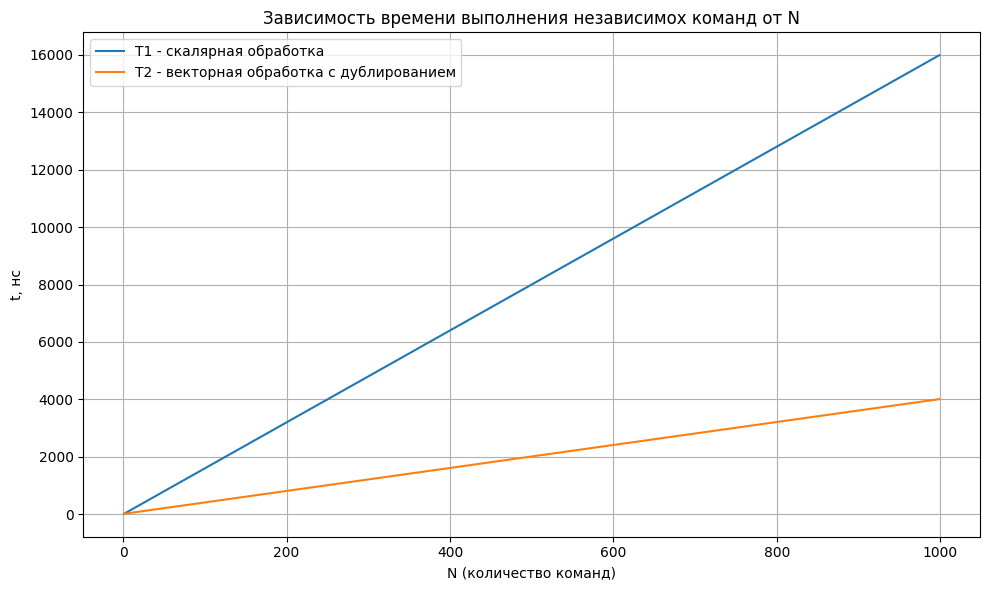

In [5]:
n = np.arange(1, 1000)

plt.figure(figsize=(10, 6))
plt.plot(n, t_serial(n), label="T1 - скалярная обработка")
plt.plot(n, t_conveyor(n), label="T2 - векторная обработка с дублированием")

plt.title("Зависимость времени выполнения независимох команд от N")
plt.xlabel("N (количество команд)")
plt.ylabel("t, нс")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

### Графики зависимости ускорения и эффективности конвеерной обработки от N

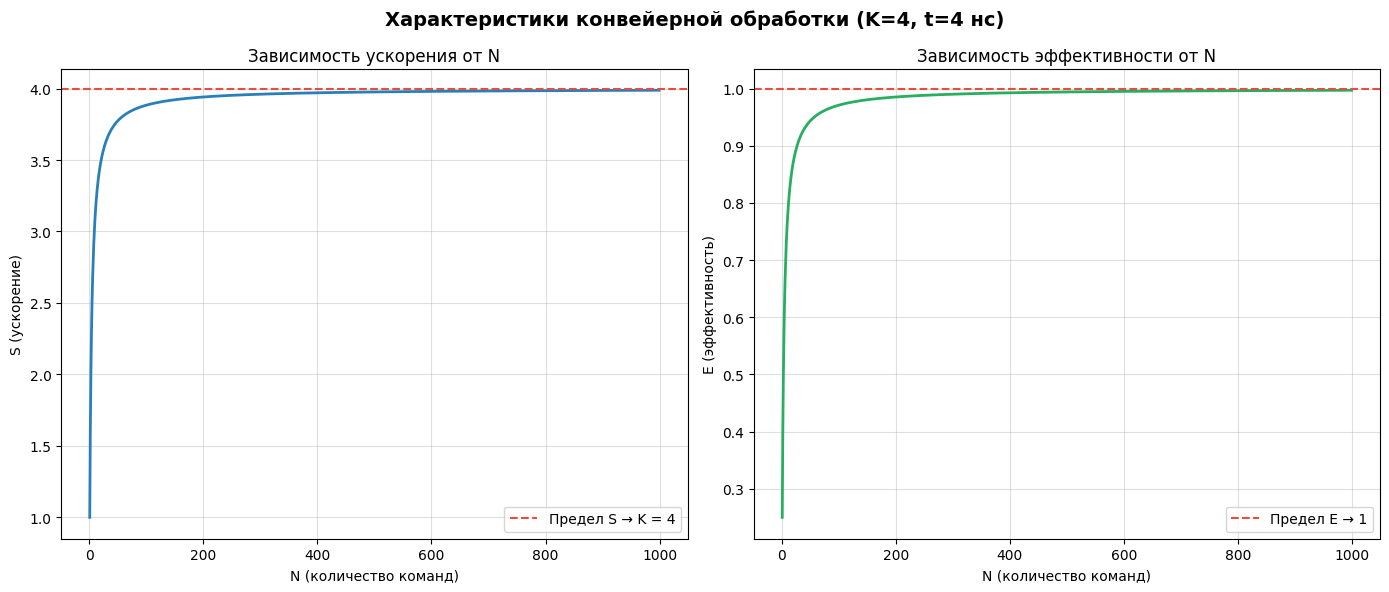

In [6]:
n = np.arange(1, 1000)
speedup = t_serial(n) / t_conveyor(n)
efficiency = speedup / d.conveyor_steps

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "Характеристики конвейерной обработки (K=4, t=4 нс)", fontsize=14, fontweight="bold"
)

ax1.plot(n, speedup, color="#2980B9", linewidth=2)
ax1.axhline(
    y=d.conveyor_steps,
    color="#E74C3C",
    linestyle="--",
    linewidth=1.5,
    label=f"Предел S → K = {d.conveyor_steps}",
)
ax1.set_title("Зависимость ускорения от N")
ax1.set_xlabel("N (количество команд)")
ax1.set_ylabel("S (ускорение)")
ax1.legend()
ax1.grid(True, alpha=0.4)

ax2.plot(n, efficiency, color="#27AE60", linewidth=2)
ax2.axhline(y=1.0, color="#E74C3C", linestyle="--", linewidth=1.5, label="Предел E → 1")
ax2.set_title("Зависимость эффективности от N")
ax2.set_xlabel("N (количество команд)")
ax2.set_ylabel("E (эффективность)")
ax2.legend()
ax2.grid(True, alpha=0.4)

plt.tight_layout()

### Временная диаграмма

Последовательность команд:

1. R1 = R2 + R3
2. R4 = R1 + R5 (зависит от R1)
3. R6 = R7 * R8 (независима)
4. R9 = R4 – R10 (зависит от R4)
5. R11 = R12 + R13 (независима)

#### Диаграмма без обхода

|Команда|1 |2 |3 |4 |5 |6 |7 |8 |9 |10|11|
|-------|--|--|--|--|--|--|--|--|--|--|--|
|1      |IF|ID|OR|EX|WB|  |  |  |  |  |  |
|2      |  |IF|ID|ST|ST|OR|EX|WB|  |  |  |
|3      |  |  |IF|ID|OR|EX|WB|  |  |  |  |
|4      |  |  |  |IF|ID|ST|ST|ST|OR|EX|WB|
|5      |  |  |  |  |IF|ID|OR|EX|WB|  |  |

#### Диаграмма с обходом

|Команда|1 |2 |3 |4 |5 |6 |7 |8 |9 |10|
|-------|--|--|--|--|--|--|--|--|--|--|
|1      |IF|ID|OR|EX|WB|  |  |  |  |  |
|2      |  |IF|ID|ST|OR|EX|WB|  |  |  |
|3      |  |  |IF|ID|OR|ST|EX|WB|  |  |
|4      |  |  |  |IF|ID|ST|OR|EX|WB|  |
|5      |  |  |  |  |IF|ID|OR|ST|EX|WB|

### Выводы

При последовательном выполнении 21 команды на 4-ступенчатом конвейере с длительностью ступени 4 нс время составило $T_{посл}$ = 336 нс, тогда как конвейерное выполнение заняло $T_{конв}$ = 96 нс — ускорение $S \approx 3.50$ при эффективности $E \approx 0.875$ (87.5%). Полученные результаты подтверждают теоретическое утверждение: при увеличении числа команд $N$ ускорение стремится к числу ступеней $K = 4$, а эффективность — к 1. Моделирование конфликтов RAW показало, что отсутствие механизма обхода данных (forwarding) приводит к принудительным остановкам конвейера (stall), увеличивая общее время выполнения; с обходом данных задержки устраняются, и производительность приближается к идеальной. Таким образом, конвейеризация даёт существенный выигрыш в производительности, однако её реальная эффективность определяется наличием конфликтов и способами их устранения.

## Задание 2. Моделирование скалярной и суперскалярной обработки

**Цель задания**: оценить влияние ширины выдачи и неупорядоченного выполнения на производительность.

### Сравнение скалярного и суперскалярного процессоров

In [7]:
def t_scalar(n):
    return (n + d.conveyor_steps - 1) * d.step_time


def t_superscalar(n, w):
    return (ceil(n / w) + d.conveyor_steps - 1) * d.step_time


t1 = t_scalar(d.ops)
t2 = t_superscalar(d.ops, 2)
t3 = t_superscalar(d.ops, d.func_blocks)

print("Исходные данные:")
print(f"K = {d.conveyor_steps}")
print(f"t = {d.step_time}")
print(f"n = {d.ops}")
print()

print(f"T1 = {t1}")
print(f"T2 = {t2}")
print(f"T3 = {t3}")

Исходные данные:
K = 4
t = 4
n = 21

T1 = 96
T2 = 56
T3 = 40


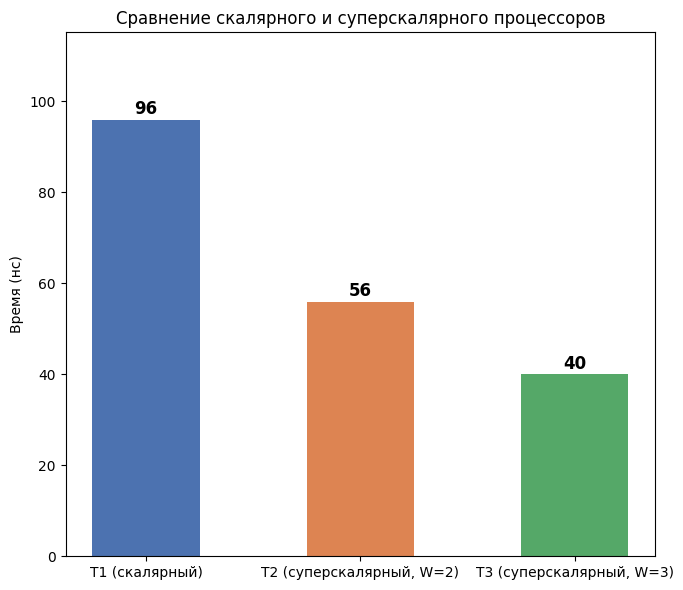

In [8]:
labels = [
    "T1 (скалярный)",
    "T2 (суперскалярный, W=2)",
    f"T3 (суперскалярный, W={d.func_blocks})",
]
values = [t1, t2, t3]
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(7, 6))
bars = ax.bar(labels, values, color=colors, width=0.5)

for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        str(val),
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
    )

ax.set_ylabel("Время (нс)")
ax.set_title("Сравнение скалярного и суперскалярного процессоров")
ax.set_ylim(0, max(values) * 1.2)
plt.tight_layout()
plt.show()

### Вренная диаграмма

#### Последовательность команд

|№  |Операция        |Тип | Зависит от|
|---|----------------|----|-----------|
|1  |R1 = R2 + R3    |АЛУ | -         |
|2  |R4 = R1 + R5    |АЛУ | 1         |
|3  |R6 = R7 * R8    |УМН | -         |
|4  |R9 = R4 – R10   |АЛУ | 2         |
|5  |R11 = R6 + R12  |АЛУ | 3         |
|6  |R13 = R11 * R14 |УМН | 5         |
|7  |R15 = R16 + R17 |АЛУ | -         |
|8  |R18 = R15 – R19 |АЛУ | 7         |
|9  |R20 = R18 * R21 |УМН | 8         |
|10 |R22 = R20 + R23 |АЛУ | 9         |

#### Упорядоченное выполнение

|Блок |1 |2 |3 |4 |5 |6 |7 |
|-----|--|--|--|--|--|--|--|
|УМН  |  |3 |3 |  |6 |6 |9 |
|АЛУ-1|1 |2 |4 |5 |7 |8 |10|
|АЛУ-2|  |  |  |  |  |  |  |

#### Неупорядоченное выполнение

|Блок |1 |2 |3 |4 |5 |6 |
|-----|--|--|--|--|--|--|
|УМН  |3 |3 |9 |9 |6 |6 |
|АЛУ-1|1 |2 |4 |  |10|  |
|АЛУ-2|7 |8 |5 |  |  |  |

### Выводы

Скалярный процессор выполнил 21 команду за $T_1 = 96 нс$; суперскалярный с шириной выдачи $W = 2$ — за $T_2 = 56 нс$ (ускорение $S_2 \approx 1.71$), а с шириной выдачи $F = 3$ - за $T_3 = 40 нс$ (ускорение $S_3 = 2.40$). Ускорение не достигает теоретического максимума ($W$ или $F$) из-за зависимостей между командами и накладных расходов на заполнение конвейера. Неупорядоченное выполнение (out-of-order) позволяет дополнительно скрыть задержки: независимые команды запускаются, не дожидаясь завершения зависимых, что заполняет простои исполнительных блоков. Следовательно, увеличение ширины выдачи эффективно только при достаточном параллелизме в программе; без него блоки простаивают, и реальное ускорение оказывается ниже теоретического.

## Задание 3. Исследование VLIW-архитектуры


**Цель задания**: научиться формировать VLIW-пакеты из независимых операций.

### Последовательность команд

1. A = B + C
2. D = E * F
3. G = H – I
4. J = K * L
5. M = N + O
6. P = Q – R
7. S = T * U
8. V = W + X
9. Y = Z + AA
10. AB = AC * AD
11. AE = AF – AG

---

12. AH = AI * AJ
13. AK = AL + AM
14. AN = AO * AP
15. AQ = AR – AS

### Временная диаграмма

|Блок |1 |2 |3 |4 |5 |6 |7 |8 |
|-----|--|--|--|--|--|--|--|--|
|УМН  |2 |2 |4 |4 |7 |7 |10|10|
|АЛУ-1|1 |5 |8 |11|  |  |  |  |
|АЛУ-2|3 |6 |9 |  |  |  |  |  |

### Выводы

Из 11 операций варианта 7 являются операциями АЛУ и 4 — умножениями; при последовательном выполнении суммарное время составляет $T_{посл}$ = 15 тактов. Благодаря статическому планированию компилятора независимые операции объединяются в VLIW-пакеты и выполняются параллельно на двух АЛУ и одном умножителе, что позволяет значительно сократить общее число тактов. Ограничивающим фактором является единственный блок умножения: четыре умножения длительностью 2 такта каждое не могут выполняться одновременно и образуют узкое место расписания. VLIW-архитектура упрощает аппаратную часть процессора, перекладывая задачу обнаружения параллелизма на компилятор, однако требует высококачественной статической оптимизации и жёстко привязана к конкретной конфигурации функциональных блоков.

## Задание 4. Анализ архитектуры памяти (UMA vs NUMA)

**Цель задания**: сравнить эффективность UMA и NUMA при разных долях локальных обращений.

### Расчёт среднего времени доступа

In [9]:
m = 1000


@np.vectorize
def t_avg_numa(p):
    return p * d.local_time + (1 - p) * d.remote_time


@np.vectorize
def t_numa(p):
    return t_avg_numa(p) * m


print("Исходные данные:")
print(f"t_loc = {d.local_time}")
print(f"t_rem = {d.remote_time}")
print(f"t_uma = {d.uma_time}")
print(f"p     = {d.numa_accesses}")
print(f"M     = {m}")
print()


print("Результаты:")
print(f"t_avg_numa = {t_avg_numa(d.numa_accesses)}")
print(f"T_numa     = {t_numa(d.numa_accesses)}")
print(f"T_uma      = {d.uma_time * m}")

Исходные данные:
t_loc = 63
t_rem = 174
t_uma = 93
p     = 0.63
M     = 1000

Результаты:
t_avg_numa = 104.07
T_numa     = 104070.0
T_uma      = 93000


### График зависимости времени доступа в NUMA от доли локальных обращений

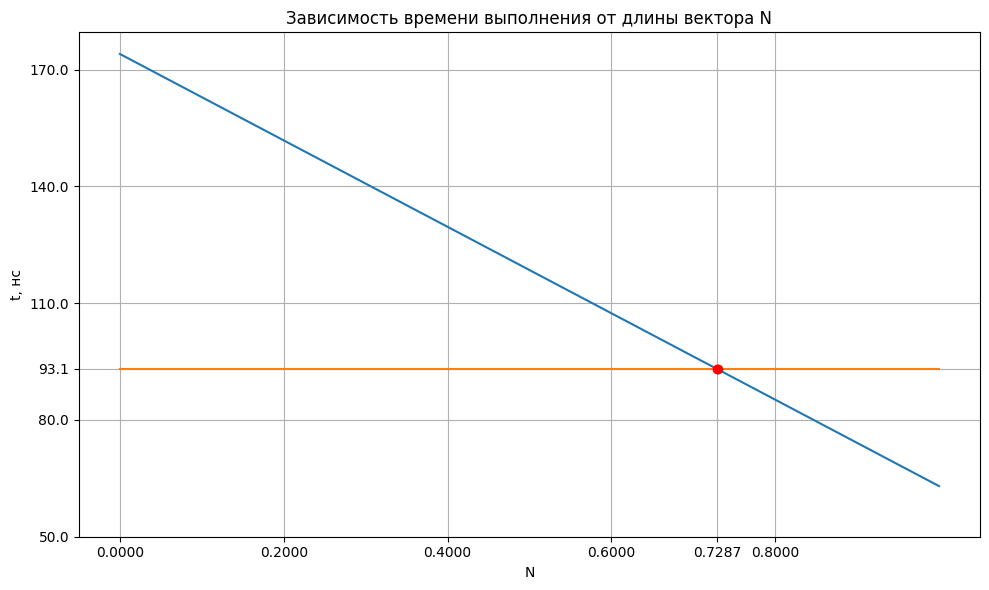

In [10]:
p = np.linspace(0, 1, 1000)
f = t_avg_numa(p)
g = np.repeat(d.uma_time, 1000)

plt.figure(figsize=(10, 6))
plt.plot(p, f)
plt.plot(p, g)
idx = np.argwhere(np.diff(np.sign(f - g))).flatten()
plt.plot(p[idx], f[idx], "ro")
plt.xticks(np.concatenate((np.arange(0, 1, 0.2), p[idx][0:1])))
plt.yticks(np.concatenate((np.arange(50, 180, 30), f[idx][0:1])))

plt.title("Зависимость времени выполнения от длины вектора N")
plt.xlabel("N")
plt.ylabel("t, нс")
plt.grid()
plt.tight_layout()
plt.show()

### Выводы

При доле локальных обращений $p = 0.63$ среднее время доступа в NUMA-системе составило $t_{avg} = 104.07 нс$, что превысило время доступа в UMA-системе $t_{UMA} = 93 нс$; суммарное время выполнения 1000 обращений — $T_{NUMA} = 104070 нс$ против $T_{UMA} = 93 000 нс$. Точка безубыточности, при которой NUMA сравнивается с UMA по скорости, находится при $p \approx 0.7287$; при $p > 0.7287$ NUMA становится выгоднее за счёт преимущественно локальных обращений с малой задержкой 63 нс. Поскольку $p = 0.63 < 0.7297$, данная программная нагрузка недостаточно локальна, и NUMA-архитектура не даёт выигрыша. Это подчёркивает ключевую роль принципа локальности данных: NUMA эффективна только при грамотном распределении памяти между процессорами и высокой доле локальных обращений.

## Задание 5. Моделирование протокола когерентности MESI

**Цель задания**: научиться отслеживать состояния кэш-строк в многопроцессорной системе при выполнении последовательности обращений.

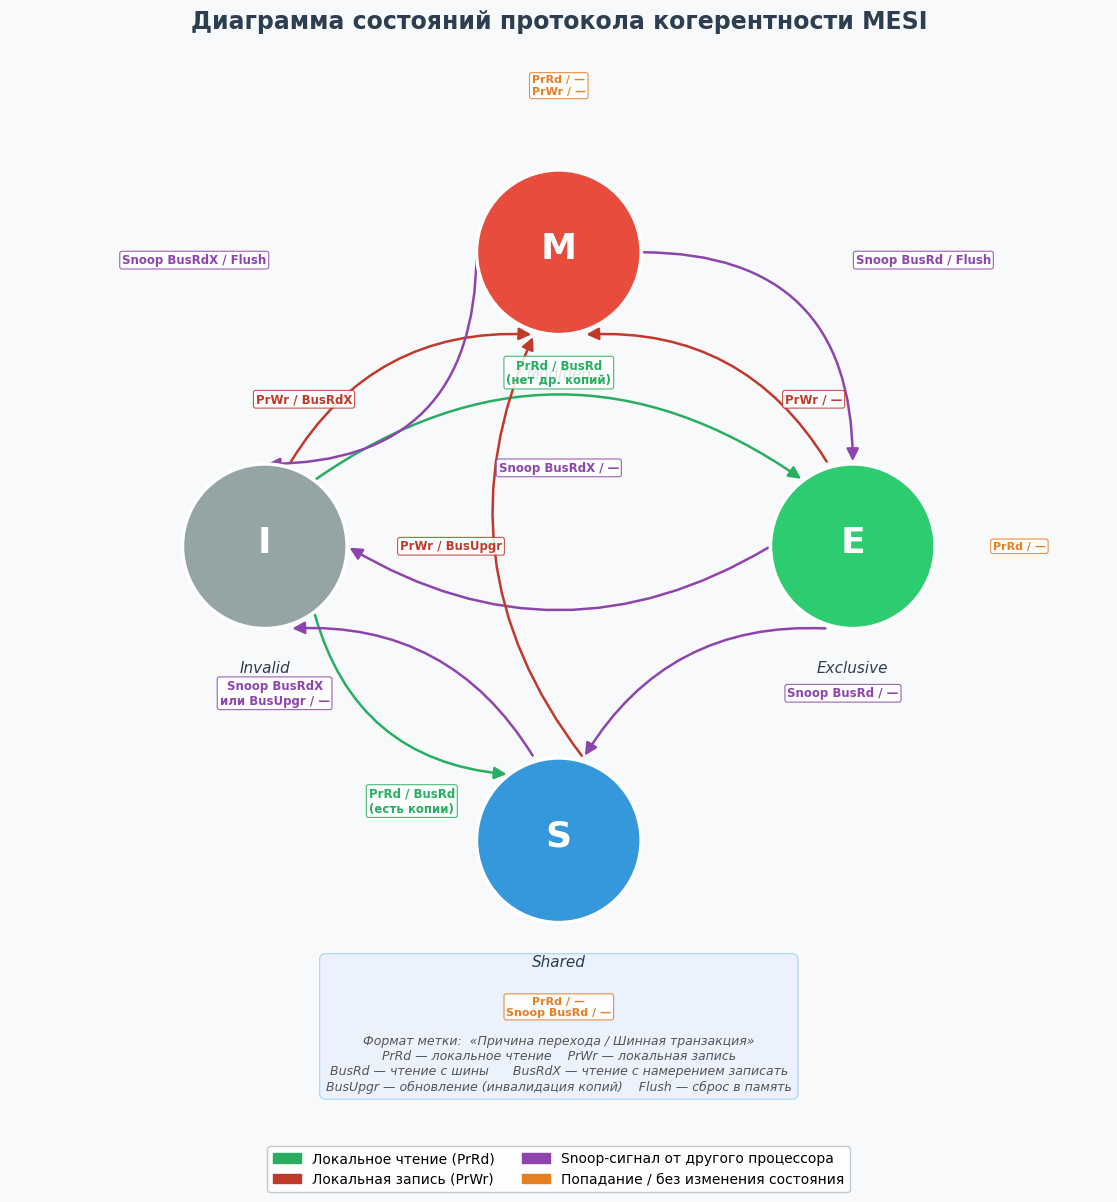

In [11]:
G = nx.MultiDiGraph()

states = ["M", "E", "S", "I"]
G.add_nodes_from(states)

pos = {
    "M": (0, 1.5),
    "E": (1.5, 0),
    "S": (0, -1.5),
    "I": (-1.5, 0),
}

node_colors = {
    "M": "#E74C3C",
    "E": "#2ECC71",
    "S": "#3498DB",
    "I": "#95A5A6",
}

transitions = [
    ("I", "E", "PrRd / BusRd\n(нет др. копий)", "#27AE60"),
    ("I", "S", "PrRd / BusRd\n(есть копии)", "#27AE60"),
    ("I", "M", "PrWr / BusRdX", "#C0392B"),
    ("E", "M", "PrWr / —", "#C0392B"),
    ("E", "S", "Snoop BusRd / —", "#8E44AD"),
    ("E", "I", "Snoop BusRdX / —", "#8E44AD"),
    ("S", "M", "PrWr / BusUpgr", "#C0392B"),
    ("S", "I", "Snoop BusRdX\nили BusUpgr / —", "#8E44AD"),
    ("M", "S", "Snoop BusRd / Flush", "#8E44AD"),
    ("M", "I", "Snoop BusRdX / Flush", "#8E44AD"),
    ("M", "M", "PrRd / —\nPrWr / —", "#E67E22"),
    ("E", "E", "PrRd / —", "#E67E22"),
    ("S", "S", "PrRd / —\nSnoop BusRd / —", "#E67E22"),
]

fig, ax = plt.subplots(figsize=(16, 14))
ax.set_aspect("equal")
ax.axis("off")

fig.patch.set_facecolor("#F8F9FA")
ax.set_facecolor("#F8F9FA")

for state, (x, y) in pos.items():
    circle = plt.Circle(
        (x, y), 0.42, color=node_colors[state], zorder=5, linewidth=2.5, ec="white"
    )
    ax.add_patch(circle)
    ax.text(
        x,
        y + 0.02,
        state,
        ha="center",
        va="center",
        fontsize=26,
        fontweight="bold",
        color="white",
        zorder=6,
    )

    full_name = {"M": "Modified", "E": "Exclusive", "S": "Shared", "I": "Invalid"}
    ax.text(
        x,
        y - 0.62,
        full_name[state],
        ha="center",
        va="center",
        fontsize=11,
        color="#2C3E50",
        style="italic",
        zorder=6,
    )


def draw_arc(ax, p1, p2, label, color, rad=0.25, label_offset=(0, 0)):
    """Рисует изогнутую стрелку и подпись."""
    arrow = FancyArrowPatch(
        p1,
        p2,
        connectionstyle=f"arc3,rad={rad}",
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=1.8,
        color=color,
        zorder=3,
    )
    ax.add_patch(arrow)

    mx = (p1[0] + p2[0]) / 2 + label_offset[0]
    my = (p1[1] + p2[1]) / 2 + label_offset[1]
    ax.text(
        mx,
        my,
        label,
        ha="center",
        va="center",
        fontsize=8.5,
        color=color,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.2", fc="white", ec=color, alpha=0.85, linewidth=0.8
        ),
        zorder=7,
    )


def draw_loop(ax, center, label, color, angle_deg=90, r=0.7):
    """Рисует петлю (self-loop) вокруг узла."""
    angle = np.deg2rad(angle_deg)
    lx = center[0] + r * np.cos(angle)
    ly = center[1] + r * np.sin(angle)

    loop = FancyArrowPatch(
        (
            center[0] + 0.38 * np.cos(angle - 0.5),
            center[1] + 0.38 * np.sin(angle - 0.5),
        ),
        (
            center[0] + 0.38 * np.cos(angle + 0.5),
            center[1] + 0.38 * np.sin(angle + 0.5),
        ),
        connectionstyle=f"arc3,rad=-2.5",
        arrowstyle="-|>",
        mutation_scale=15,
        linewidth=1.6,
        color=color,
        zorder=3,
    )
    ax.add_patch(loop)
    ax.text(
        lx,
        ly,
        label,
        ha="center",
        va="center",
        fontsize=8,
        color=color,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.2", fc="white", ec=color, alpha=0.85, linewidth=0.8
        ),
        zorder=7,
    )


R = 0.42

draw_arc(
    ax,
    (pos["I"][0] + R * 0.6, pos["I"][1] + R * 0.8),
    (pos["E"][0] - R * 0.6, pos["E"][1] + R * 0.8),
    "PrRd / BusRd\n(нет др. копий)",
    "#27AE60",
    rad=-0.35,
    label_offset=(0, 0.55),
)

draw_arc(
    ax,
    (pos["I"][0] + R * 0.6, pos["I"][1] - R * 0.8),
    (pos["S"][0] - R * 0.6, pos["S"][1] + R * 0.8),
    "PrRd / BusRd\n(есть копии)",
    "#27AE60",
    rad=0.35,
    label_offset=(0, -0.55),
)

draw_arc(
    ax,
    (pos["I"][0] + R * 0.3, pos["I"][1] + R),
    (pos["M"][0] - R * 0.3, pos["M"][1] - R),
    "PrWr / BusRdX",
    "#C0392B",
    rad=-0.3,
    label_offset=(-0.55, 0),
)

draw_arc(
    ax,
    (pos["E"][0] - R * 0.3, pos["E"][1] + R),
    (pos["M"][0] + R * 0.3, pos["M"][1] - R),
    "PrWr / —",
    "#C0392B",
    rad=0.3,
    label_offset=(0.55, 0),
)

draw_arc(
    ax,
    (pos["E"][0] - R * 0.3, pos["E"][1] - R),
    (pos["S"][0] + R * 0.3, pos["S"][1] + R),
    "Snoop BusRd / —",
    "#8E44AD",
    rad=0.3,
    label_offset=(0.7, 0),
)

draw_arc(
    ax,
    (pos["E"][0] - R, pos["E"][1]),
    (pos["I"][0] + R, pos["I"][1]),
    "Snoop BusRdX / —",
    "#8E44AD",
    rad=-0.3,
    label_offset=(0, 0.4),
)

draw_arc(
    ax,
    (pos["S"][0] + R * 0.3, pos["S"][1] + R),
    (pos["M"][0] - R * 0.3, pos["M"][1] - R),
    "PrWr / BusUpgr",
    "#C0392B",
    rad=-0.3,
    label_offset=(-0.55, 0),
)

draw_arc(
    ax,
    (pos["S"][0] - R * 0.3, pos["S"][1] + R),
    (pos["I"][0] + R * 0.3, pos["I"][1] - R),
    "Snoop BusRdX\nили BusUpgr / —",
    "#8E44AD",
    rad=0.3,
    label_offset=(-0.7, 0),
)

draw_arc(
    ax,
    (pos["M"][0] + R, pos["M"][1]),
    (pos["E"][0], pos["E"][1] + R),
    "Snoop BusRd / Flush",
    "#8E44AD",
    rad=-0.5,
    label_offset=(0.9, 0.5),
)

draw_arc(
    ax,
    (pos["M"][0] - R, pos["M"][1]),
    (pos["I"][0], pos["I"][1] + R),
    "Snoop BusRdX / Flush",
    "#8E44AD",
    rad=-0.5,
    label_offset=(-0.9, 0.5),
)

draw_loop(ax, pos["M"], "PrRd / —\nPrWr / —", "#E67E22", angle_deg=90, r=0.85)
draw_loop(ax, pos["E"], "PrRd / —", "#E67E22", angle_deg=0, r=0.85)
draw_loop(ax, pos["S"], "PrRd / —\nSnoop BusRd / —", "#E67E22", angle_deg=270, r=0.85)

legend_elements = [
    mpatches.Patch(color="#27AE60", label="Локальное чтение (PrRd)"),
    mpatches.Patch(color="#C0392B", label="Локальная запись (PrWr)"),
    mpatches.Patch(color="#8E44AD", label="Snoop-сигнал от другого процессора"),
    mpatches.Patch(color="#E67E22", label="Попадание / без изменения состояния"),
]
ax.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.06),
    ncol=2,
    fontsize=10,
    framealpha=0.9,
    edgecolor="#BDC3C7",
)

ax.set_title(
    "Диаграмма состояний протокола когерентности MESI",
    fontsize=17,
    fontweight="bold",
    color="#2C3E50",
    pad=20,
)

info = (
    "\n"
    "\n"
    "\n"
    "\n"
    "\n"
    "Формат метки:  «Причина перехода / Шинная транзакция»\n"
    "PrRd — локальное чтение    PrWr — локальная запись\n"
    "BusRd — чтение с шины      BusRdX — чтение с намерением записать\n"
    "BusUpgr — обновление (инвалидация копий)    Flush — сброс в память"
)
ax.text(
    0,
    -2.45,
    info,
    ha="center",
    va="center",
    fontsize=9,
    color="#555",
    style="italic",
    bbox=dict(boxstyle="round,pad=0.5", fc="#EAF2FF", ec="#AED6F1", alpha=0.9),
)

ax.set_xlim(-2.8, 2.8)
ax.set_ylim(-3.0, 2.5)

plt.show()

### Таблица переходов состояний

| Шаг | Проц | Операция | P0 до | P1 до | Рез-т | Шинная транзакция | P0 после | P1 после |
|:---:|:----:|:--------:|:-----:|:-----:|:-----:|:-----------------:|:--------:|:--------:|
| 1 | P0 | Read X  | `I` | `I` | Miss | `BusRd` (копий нет → E) | `E` | `I` |
| 2 | P1 | Read X  | `E` | `I` | Miss | `BusRd`; P0: E→S (Snoop BusRd) | `S` | `S` |
| 3 | P0 | Write X | `S` | `S` | Hit* | `BusUpgr`; P1: S→I (Snoop BusUpgr) | `M` | `I` |
| 4 | P1 | Read X  | `M` | `I` | Miss | `BusRd`; P0: M→S + `Flush` | `S` | `S` |
| 5 | P1 | Write X | `S` | `S` | Hit* | `BusUpgr`; P0: S→I (Snoop BusUpgr) | `I` | `M` |
| 6 | P0 | Read X  | `I` | `M` | Miss | `BusRd`; P1: M→S + `Flush` | `S` | `S` |

\* Hit — данные есть в кэше, но требуется шинная транзакция для инвалидации других копий.

---

### Пояснения к каждому шагу

#### Шаг 1 — P0: Read X

- P0 не имеет строки X (`I` → промах).
- P0 выдаёт **BusRd** на шину. P1 проверяет свой кэш — тоже `I`, данных нет.
- Данные загружаются из основной памяти. Так как других копий нет, P0 получает **исключительное** владение.
- **P0: I → E**, P1 остаётся `I`.

#### Шаг 2 — P1: Read X

- P1 не имеет строки X (`I` → промах).
- P1 выдаёт **BusRd** на шину. P0 наблюдает (snoop) BusRd — у него строка в состоянии `E`.
- По правилу протокола: при snoop BusRd из состояния `E` процессор должен перейти в `S` (данные становятся разделяемыми).
- P1 получает данные и тоже переходит в `S`.
- **P0: E → S**, **P1: I → S**.

#### Шаг 3 — P0: Write X

- P0 хочет записать в X, текущее состояние `S` (попадание по данным, но не по правам).
- P0 выдаёт **BusUpgr** — запрос на повышение прав (инвалидация всех копий).
- P1 наблюдает BusUpgr, у него строка в `S` → **P1: S → I**.
- P0 получает эксклюзивное право на запись и переходит в `M` (данные изменены, в основную память не записаны).
- **P0: S → M**, **P1: S → I**.

#### Шаг 4 — P1: Read X

- P1 не имеет строки X (`I` → промах).
- P1 выдаёт **BusRd** на шину. P0 наблюдает BusRd — у него строка в `M` (грязные данные!).
- P0 обязан выполнить **Flush** — сбросить изменённые данные в основную память (и/или передать напрямую P1).
- После сброса P0 переходит в `S`, P1 получает актуальные данные и тоже становится `S`.
- **P0: M → S** (+ Flush), **P1: I → S**.

#### Шаг 5 — P1: Write X

- P1 хочет записать в X, текущее состояние `S` (попадание по данным, но не по правам).
- P1 выдаёт **BusUpgr** на шину.
- P0 наблюдает BusUpgr, у него строка в `S` → **P0: S → I**.
- P1 получает эксклюзивное право и переходит в `M`.
- **P0: S → I**, **P1: S → M**.

#### Шаг 6 — P0: Read X

- P0 не имеет строки X (`I` → промах).
- P0 выдаёт **BusRd** на шину. P1 наблюдает BusRd — у него строка в `M`.
- P1 выполняет **Flush** (сброс в память / передача P0), переходит в `S`.
- P0 получает актуальные данные и переходит в `S`.
- **P0: I → S**, **P1: M → S** (+ Flush).

### Итоговая сводка

| Состояние | Значение |
|:---------:|:---------|
| `M` (Modified)  | Строка изменена, только в этом кэше; память устарела |
| `E` (Exclusive) | Строка только в этом кэше, совпадает с памятью |
| `S` (Shared)    | Строка в нескольких кэшах, совпадает с памятью |
| `I` (Invalid)   | Строка недействительна (отсутствует в кэше) |

| Транзакция | Назначение |
|:----------:|:-----------|
| `BusRd`    | Запрос чтения строки (при промахе чтения) |
| `BusRdX`   | Запрос чтения с намерением записать (при промахе записи) |
| `BusUpgr`  | Инвалидация чужих копий (при записи в строку `S`) |
| `Flush`    | Сброс изменённых данных в память (из состояния `M`) |

# Вывод

В ходе лабораторной работы были исследованы основные архитектурные методы повышения производительности вычислительных систем. Конвейеризация обеспечивает кратное ускорение ($S \approx 3.50$ при $K = 4$) при небольших затратах на реализацию, однако её эффективность снижается из-за конфликтов по данным и управлению. Суперскалярная архитектура и VLIW позволяют выйти за рамки ускорения одного конвейера за счёт параллельного запуска нескольких операций, но требуют либо сложной аппаратной логики (суперскаляр), либо интеллектуального компилятора (VLIW). Организация памяти оказывает принципиальное влияние на производительность многопроцессорных систем: NUMA выгодна только при высокой локальности обращений ($p > 0.73$ для данного варианта), иначе UMA с унифицированным временем доступа предпочтительнее. Наконец, корректная работа кэш-памяти в многопроцессорной среде требует протоколов когерентности — таких как MESI, — которые обеспечивают согласованность данных ценой дополнительных шинных транзакций. Совокупное применение всех рассмотренных методов позволяет добиться максимальной производительности современных вычислительных систем.